# IntentPair — one page or two?
**PE6201 End-of-Course Project · Jiayao Ge (Section B)**

Pipeline: 82 company seed keywords + 25 adversarial keywords (authored by a different model) → ~140 pairs → Google Top-10 via Serper.dev (ground truth) → LLM classification via OpenRouter → evaluation vs two baselines.

**Requirements:** ① A Serper.dev API key (2,500 free searches; this project uses about 110) ② An OpenRouter API key

**Execution order:** Run the cells from top to bottom. SERP and LLM calls are cached locally, so rerunning does not incur duplicate charges.
⚠️ Files are lost when a Colab session disconnects. After completing the relevant steps, download `data/adv_pairs.json`, `data/serp_snapshot.json`, `data/serp_meta.json`, and `data/ground_truth.csv` (these are frozen artifacts; regenerating them may change the results).

In [1]:
#@title Step 0 · Keys & config (Colab Secrets)
from google.colab import userdata

def optional_secret(name):
    try:
        return userdata.get(name)
    except Exception:
        return None

SERPER_KEY = optional_secret("SERPER_API_KEY")
OPENROUTER_KEY = optional_secret("OPENROUTER_API_KEY")
print("API credentials available:", {"Serper": bool(SERPER_KEY), "OpenRouter": bool(OPENROUTER_KEY)})

MODEL = "openai/gpt-4o-mini"          # Classifier model
ADV_MODEL = "anthropic/claude-haiku-4.5"  # Adversarial-keyword generator; must differ from the classifier
SEED = 42                              # Random seed used throughout the pipeline
SERP_LOCATION = {"gl": "sg", "hl": "en"}  # Fixed location/language: Singapore, English
print("config ok")

config ok


### Step 0b · Mount Google Drive (strongly recommended)
Each new Colab runtime clears its local files. The frozen artifacts (`data/adv_pairs.json`, `data/serp_snapshot.json`, `data/ground_truth.csv`, and `data/llm_cache.json`) would be lost; rerunning would refetch the SERPs and could change the labels.
After Drive is mounted, all files are written to `MyDrive/IntentPair/`. They survive reconnection, **and cached calls do not consume API quota again**.

In [3]:
USE_DRIVE = True   # Set to False to keep files only in the current runtime

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = "/content/drive/MyDrive/IntentPair"
    os.makedirs(WORK_DIR, exist_ok=True)
    os.chdir(WORK_DIR)
else:
    WORK_DIR = os.getcwd()

DATA_DIR = os.path.join(WORK_DIR, "data")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("working dir:", WORK_DIR)
print("existing frozen assets:", sorted(os.listdir(DATA_DIR)) or "(none yet)")

Mounted at /content/drive
working dir: /content/drive/MyDrive/IntentPair
existing frozen assets: (none yet)


In [4]:
#@title Step 1 · Seed keywords (82, from my company's SEO keyword list)
KEYWORDS = [
    "Email Verifier",
    "Email Finder",
    "Reverse Email Lookup",
    "google maps scraper",
    "b2b Lead Generator",
    "Contact Finder",
    "Data Enrichment Tool",
    "Decision Maker Finder",
    "Company Finder",
    "Lead Scoring",
    "Find Business Telephone Number",
    "Youtube Channel Finder",
    "Influencer Finder Tool",
    "Influencer Analysis Tool",
    "Talent Finder",
    "Search Resumes",
    "Cofounder Matching",
    "Local Business Finder",
    "Linkedin Scraper",
    "Linkedin Email Finder",
    "AI Copywriting",
    "AI Email Generator",
    "Company Profile Generator",
    "Lead Enrichment Tool",
    "Sales prospecting tools",
    "Instagram Influencer Finder",
    "Lead Generator",
    "CEO Finder",
    "Board Member Search",
    "TikTok Influencer Finder",
    "Lead List Builder",
    "people finder",
    "Buyer Intent Data Tool",
    "Business Owner Lookup",
    "Candidate Sourcing Tool",
    "Creator Finder",
    "LinkedIn job scraper",
    "LinkedIn profile scraper",
    "LinkedIn post scraper",
    "LinkedIn sales navigator scraper",
    "LinkedIn phone number finder",
    "LinkedIn contact finder",
    "Google maps email scraper",
    "Twitter media scraper",
    "Twitter profile scraper",
    "Twitter email finder",
    "Twitter image scraper",
    "Twitter profile search",
    "Ad Library Scraper",
    "Facebook Ad Scraper",
    "Facebook profile scraper",
    "Facebook contact finder",
    "Facebook email finder",
    "Facebook automation tool",
    "Instagram email scraper",
    "Instagram phone number scraper",
    "Instagram post scraper",
    "Instagram contact finder",
    "Instagram email finder",
    "Instagram lead generation tool",
    "Instagram automation tool",
    "LinkedIn profile post scraper",
    "TikTok profile scraper",
    "TikTok email finder",
    "Google email scraper",
    "Google lead scraper",
    "Google Search Scraper",
    "Google email finder",
    "Website email finder",
    "Website data extractor",
    "RAG Web Browser",
    "Web contact scraper",
    "email scraper",
    "Instagram profile scraper",
    "YouTube email finder",
    "TikTok hashtag scraper",
    "TikTok hashtag generator",
    "TikTok follower scraper",
    "Amazon seller tool",
    "Facebook scraper",
    "Facebook post scraper",
    "Facebook Search Scraper"
]
seen, keywords = set(), []
for k in KEYWORDS:
    if k.lower() not in seen:
        seen.add(k.lower()); keywords.append(k.strip())
print(len(keywords), "unique keywords")

82 unique keywords


## Step 1.5 · Adversarial keywords (generated by a second model)
The Problem Statement commits to generating some test pairs with **a model different from the classifier**, avoiding a self-authored evaluation.
Generate the pairs once, then freeze them in `data/adv_pairs.json` (⚠️ download a backup afterward; both the generator and its output should be committed to the repository).
Each pair contains one real base keyword and one challenging variant (pricing / best / vs / free / how-to / singular or plural), mixing cases where intent is preserved with cases where it changes.

In [5]:
import json, os, re, requests

ADV_FILE = os.path.join(DATA_DIR, "adv_pairs.json")

def extract_json(text):
    """The LLM may wrap its response in a ```json fence or add explanatory text; strip both."""
    if not text or not text.strip():
        raise ValueError("model returned empty content")
    t = text.strip()
    t = re.sub(r"^```(?:json)?\s*", "", t)
    t = re.sub(r"\s*```$", "", t)
    try:
        return json.loads(t)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", t, re.S)          # Capture the first {...} object
        if m: return json.loads(m.group(0))
        raise

if os.path.exists(ADV_FILE):
    adv_pairs = json.load(open(ADV_FILE))
    print("loaded frozen adversarial pairs")
else:
    assert OPENROUTER_KEY, "OPENROUTER_API_KEY is required when adv_pairs.json is not cached"
    prompt = (
        "Here is a list of B2B lead-generation SaaS keywords:\n"
        + json.dumps(keywords) +
        "\n\nCreate exactly 25 adversarial keyword pairs for testing a search-intent classifier. "
        "For each pair, pick one base keyword FROM THE LIST ABOVE and write ONE new variant keyword "
        "that is lexically similar but tricky:\n"
        "- modifier variants: pricing / best / free / alternative / vs\n"
        "- informational variants: 'how to ...' phrasing\n"
        "- singular/plural or synonym swaps\n"
        "Mix cases where the variant likely keeps the same Google search intent and cases where it changes it.\n"
        'Reply with ONLY a JSON object, no prose, no code fences: {"pairs": [{"base": "...", "variant": "..."}]}'
    )
    r = requests.post("https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization": f"Bearer {OPENROUTER_KEY}"},
        json={"model": ADV_MODEL, "temperature": 0.7, "max_tokens": 4000,
              "messages": [{"role": "user", "content": prompt}]},
        timeout=180)
    r.raise_for_status()
    body = r.json()
    msg = body["choices"][0]["message"]
    content = msg.get("content") or ""
    try:
        adv_pairs = extract_json(content)["pairs"]
    except Exception as e:
        print("❌ Parsing failed:", e)
        print("finish_reason =", body["choices"][0].get("finish_reason"))
        print("--- raw content (first 2,000 characters) ---")
        print(content[:2000] if content else "(empty)")
        print("--- full message keys ---", list(msg.keys()))
        raise
    json.dump(adv_pairs, open(ADV_FILE, "w"))
    print("generated & frozen", len(adv_pairs), "pairs")

# Normalize: base must map to the list's **original spelling/casing** (models often change case), and variant must be new
canon = {k.lower(): k for k in keywords}
cleaned, seen_var = [], set()
for p in adv_pairs:
    base = canon.get(str(p.get("base", "")).strip().lower())
    var = str(p.get("variant", "")).strip()
    if not base or not var: continue
    vl = var.lower()
    if vl in canon or vl in seen_var: continue      # Variants cannot duplicate an existing keyword or one another
    seen_var.add(vl)
    cleaned.append({"base": base, "variant": var})
adv_pairs = cleaned[:25]
all_keywords = keywords + [p["variant"] for p in adv_pairs]
assert len(set(k.lower() for k in all_keywords)) == len(all_keywords), "keyword casing collision"
print(len(adv_pairs), "adversarial pairs;", len(all_keywords), "keywords total (incl. variants)")
for p in adv_pairs[:5]: print("  ", p["base"], " | ", p["variant"])

generated & frozen 25 pairs
25 adversarial pairs; 107 keywords total (incl. variants)
   Email Verifier  |  Email Verifier Pricing
   Email Finder  |  How to Find Email Addresses
   b2b Lead Generator  |  Best B2B Lead Generation Tools
   Contact Finder  |  Contact Finder vs Email Finder
   Data Enrichment Tool  |  Free Data Enrichment Tool


## Step 2 · Pair generation (the generator is part of the system and its script belongs in the repository)
Stratified sampling by token Jaccard similarity plus adversarial pairs, for 140 pairs in total:
- **high (J≥0.5)** ×45 — difficult cases involving near-synonyms or platform changes
- **mid (0.2≤J<0.5)** ×40 — gray-area cases
- **low (J<0.2)** ×30 — unrelated controls
- **adversarial** ×25 — generated by a second model in Step 1.5

The pairs are then stratified by label into 20 development pairs (the few-shot source, excluded from scoring) and 120 test pairs.

In [6]:
import itertools, random, re
import pandas as pd

def toks(k): return set(re.findall(r"[a-z0-9]+", k.lower()))
def jaccard(a, b):
    A, B = toks(a), toks(b)
    return len(A & B) / len(A | B)

all_pairs = [(a, b, jaccard(a, b)) for a, b in itertools.combinations(keywords, 2)]
strata = {
    "high": [p for p in all_pairs if p[2] >= 0.5],
    "mid":  [p for p in all_pairs if 0.2 <= p[2] < 0.5],
    "low":  [p for p in all_pairs if p[2] < 0.2],
}
rng = random.Random(SEED)
sample = (rng.sample(strata["high"], 45) + rng.sample(strata["mid"], 40)
          + rng.sample(strata["low"], 30))
pairs = pd.DataFrame(sample, columns=["kw_a", "kw_b", "jaccard"])
pairs["source"] = "sampled"
adv_df = pd.DataFrame([{"kw_a": p["base"], "kw_b": p["variant"],
                        "jaccard": jaccard(p["base"], p["variant"]),
                        "source": "adversarial"} for p in adv_pairs])
pairs = pd.concat([pairs, adv_df], ignore_index=True)
pairs.insert(0, "pair_id", range(len(pairs)))
pairs.to_csv(os.path.join(DATA_DIR, "pairs.csv"), index=False)
print(pairs.source.value_counts()); pairs.sample(8, random_state=SEED)

source
sampled        115
adversarial     25
Name: count, dtype: int64


,pair_id,kw_a,kw_b,jaccard,source
108,108,Lead List Builder,Instagram post scraper,0.00,sampled
67,67,Company Profile Generator,LinkedIn profile scraper,0.20,sampled
31,31,TikTok email finder,YouTube email finder,0.50,sampled
119,119,Data Enrichment Tool,Free Data Enrichment Tool,0.75,adversarial
42,42,TikTok profile scraper,TikTok hashtag scraper,0.50,sampled
12,12,Facebook Ad Scraper,Facebook post scraper,0.50,sampled
81,81,Linkedin Email Finder,LinkedIn profile scraper,0.20,sampled
69,69,Local Business Finder,Google email finder,0.20,sampled


## Step 3 · Ground truth: Google Top-10 via Serper.dev
Fetch each keyword (including adversarial variants) once: approximately 110 queries completed in one collection window, with gl=sg / hl=en fixed, then freeze the snapshot.
**Leakage control: SERP data never enters the LLM prompt.**

In [7]:
import json, time, requests, os
from urllib.parse import urlparse
from datetime import datetime, timezone

CACHE_FILE = os.path.join(DATA_DIR, "serp_snapshot.json")
META_FILE = os.path.join(DATA_DIR, "serp_meta.json")
serp_cache = json.load(open(CACHE_FILE)) if os.path.exists(CACHE_FILE) else {}
serp_meta = json.load(open(META_FILE)) if os.path.exists(META_FILE) else {}
new_serp_queries = 0

def fetch_serp(kw):
    global new_serp_queries, serp_meta
    if kw in serp_cache:
        return serp_cache[kw]
    assert SERPER_KEY, "SERPER_API_KEY is required for uncached SERP queries"
    r = requests.post("https://google.serper.dev/search",
        headers={"X-API-KEY": SERPER_KEY, "Content-Type": "application/json"},
        json={"q": kw, "num": 10, **SERP_LOCATION}, timeout=30)
    r.raise_for_status()
    organic = r.json().get("organic", [])[:10]
    serp_cache[kw] = [{"url": o.get("link"), "title": o.get("title")} for o in organic]
    new_serp_queries += 1
    json.dump(serp_cache, open(CACHE_FILE, "w"))   # Persist after every call so an interrupted run can resume
    if not any(k in serp_meta for k in ("snapshot_created_at", "snapshot_created_on")):
        serp_meta["snapshot_created_at"] = datetime.now(timezone.utc).isoformat()
    serp_meta.update({"location": SERP_LOCATION, "keywords_cached": len(serp_cache)})
    json.dump(serp_meta, open(META_FILE, "w"), indent=2)
    time.sleep(0.4)
    return serp_cache[kw]

for i, kw in enumerate(all_keywords):
    fetch_serp(kw)
    if (i + 1) % 10 == 0: print(f"{i+1}/{len(all_keywords)} fetched")
serp_meta.update({"location": SERP_LOCATION, "keywords_cached": len(serp_cache)})
serp_meta.setdefault("freeze_policy", "Initial snapshot; do not overwrite with drift or reproduction runs.")
json.dump(serp_meta, open(META_FILE, "w"), indent=2)
print("done —", len(serp_cache), "keywords snapshotted;", new_serp_queries, "new queries. ⚠️ Keep the frozen snapshot.")

10/107 fetched
20/107 fetched
30/107 fetched
40/107 fetched
50/107 fetched
60/107 fetched
70/107 fetched
80/107 fetched
90/107 fetched
100/107 fetched
done — 107 keywords snapshotted. ⚠️ Download a backup of serp_snapshot.json


,serp_overlap
count,140.000000
mean,0.125000
std,0.197862
min,0.000000
25%,0.000000
50%,0.000000
75%,0.111111
max,0.900000


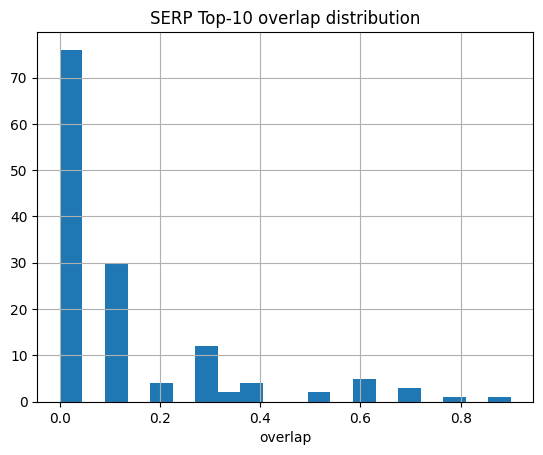

In [8]:
#@title Step 3b · SERP overlap score per pair
def norm_url(u):
    if not u: return None
    p = urlparse(u)
    host = p.netloc.lower().removeprefix("www.")
    return host + p.path.rstrip("/")

def overlap(kw_a, kw_b):
    A = {norm_url(x["url"]) for x in serp_cache[kw_a]} - {None}
    B = {norm_url(x["url"]) for x in serp_cache[kw_b]} - {None}
    denom = min(len(A), len(B))
    return len(A & B) / denom if denom else 0.0

pairs["serp_overlap"] = [overlap(a, b) for a, b in zip(pairs.kw_a, pairs.kw_b)]
ax = pairs.serp_overlap.hist(bins=20)
ax.set_title("SERP Top-10 overlap distribution"); ax.set_xlabel("overlap")
pairs.serp_overlap.describe()

### Step 3c · Set thresholds → freeze the ground truth
Choose X and Y after inspecting the distribution above (**they must be fixed before any LLM evaluation and must not be changed afterward**).
Defaults: overlap ≥ 0.3 → Same; overlap ≤ 0.0 → Different; values in between → Uncertain.

In [10]:
THRESH_SAME = 0.3   # X — may be adjusted after inspecting the distribution; freeze before evaluation
THRESH_DIFF = 0.0   # Y

def label(o):
    if o >= THRESH_SAME: return "Same"
    if o <= THRESH_DIFF: return "Different"
    return "Uncertain"

pairs["truth"] = pairs.serp_overlap.map(label)
print(pairs.truth.value_counts())

rng = random.Random(SEED)
dev_idx = []
for lab, grp in pairs.groupby("truth"):
    n = max(1, round(20 * len(grp) / len(pairs)))
    dev_idx += rng.sample(list(grp.index), min(n, len(grp)))
pairs["split"] = ["dev" if i in dev_idx else "test" for i in pairs.index]
pairs.to_csv(os.path.join(DATA_DIR, "ground_truth.csv"), index=False)
print(pairs.split.value_counts())
print("⚠️ ground_truth.csv is now frozen — download a backup and use this file for all subsequent evaluation")

truth
Different    76
Uncertain    34
Same         30
Name: count, dtype: int64
split
test    120
dev      20
Name: count, dtype: int64
⚠️ ground_truth.csv is now frozen — download a backup and use this file for all subsequent evaluation


### Step 3d · Drift check (rerun during submission week)
Because the ground-truth labels are derived from a single 24-hour SERP snapshot, they may be sensitive to temporal drift. **During the submission week**, 20 pairs (approximately 40 queries) will be re-collected, and the number of label changes will be reported. This drift check provides a low-cost estimate of the temporal stability of the downstream evaluation.
- **Skip this cell** on the notebook's initial run (before submission week).
- During submission week, set `RUN_DRIFT_CHECK = True` and rerun it. The cell bypasses `serp_cache` to refetch the keywords in 20 pairs, saves them separately to `data/drift_snapshot.json` with provenance in `data/drift_meta.json`, and does not overwrite the frozen ground truth.
**Submission-week result (2026-09-29):** 4/20 labels moved; overlap MAE = 0.030. All four changes were between Different and Uncertain; none moved to or from Same.


In [ ]:
RUN_DRIFT_CHECK = False   # Set to True during submission week

if RUN_DRIFT_CHECK:
    import json, requests, time, os
    from datetime import datetime, timezone
    DRIFT_FILE = os.path.join(DATA_DIR, "drift_snapshot.json")
    DRIFT_META_FILE = os.path.join(DATA_DIR, "drift_meta.json")
    drift_cache = json.load(open(DRIFT_FILE)) if os.path.exists(DRIFT_FILE) else {}
    drift_meta = json.load(open(DRIFT_META_FILE)) if os.path.exists(DRIFT_META_FILE) else {}
    drift_pairs = pairs.sample(20, random_state=SEED).reset_index(drop=True)
    drift_kws = sorted(set(drift_pairs.kw_a) | set(drift_pairs.kw_b))
    for j, kw in enumerate(drift_kws):
        if kw in drift_cache: continue
        assert SERPER_KEY, "SERPER_API_KEY is required for uncached drift queries"
        r = requests.post("https://google.serper.dev/search",
            headers={"X-API-KEY": SERPER_KEY, "Content-Type": "application/json"},
            json={"q": kw, "num": 10, **SERP_LOCATION}, timeout=30)
        r.raise_for_status()
        organic = r.json().get("organic", [])[:10]
        drift_cache[kw] = [{"url": o.get("link"), "title": o.get("title")} for o in organic]
        if not any(k in drift_meta for k in ("collected_at", "collected_on")):
            drift_meta["collected_at"] = datetime.now(timezone.utc).isoformat()
        json.dump(drift_cache, open(DRIFT_FILE, "w"))
        time.sleep(0.4)
        if (j + 1) % 5 == 0: print(f"drift {j+1}/{len(drift_kws)}")

    drift_meta.update({"location": SERP_LOCATION, "random_seed": SEED,
                       "pair_count": len(drift_pairs), "unique_keyword_count": len(drift_kws),
                       "purpose": "Submission-week drift audit; does not overwrite frozen labels."})
    json.dump(drift_meta, open(DRIFT_META_FILE, "w"), indent=2)

    def overlap_now(a, b):
        A = {norm_url(x["url"]) for x in drift_cache[a]} - {None}
        B = {norm_url(x["url"]) for x in drift_cache[b]} - {None}
        d = min(len(A), len(B)); return len(A & B) / d if d else 0.0

    drift_pairs["overlap_now"] = [overlap_now(a, b) for a, b in zip(drift_pairs.kw_a, drift_pairs.kw_b)]
    drift_pairs["label_now"] = drift_pairs.overlap_now.map(label)
    drift_pairs.to_csv(os.path.join(RESULTS_DIR, "drift_results.csv"), index=False)
    flipped = drift_pairs[drift_pairs.label_now != drift_pairs.truth]
    print(f"Drift check @ {datetime.now().date()}: {len(flipped)}/{len(drift_pairs)} labels moved")
    print(f"Overlap MAE = {(drift_pairs.overlap_now - drift_pairs.serp_overlap).abs().mean():.3f}")
    if len(flipped):
        print("\nFlipped pairs:")
        print(flipped[["kw_a", "kw_b", "serp_overlap", "overlap_now", "truth", "label_now"]].to_string())
else:
    print("Drift check skipped — rerun during submission week")

## Step 4 · Baselines
- **B1 majority class:** always predicts the most frequent class
- **B2 lexical rule:** synonym mapping + token Jaccard + thresholds (grid-searched on the development set only; the test set is untouched)

In [11]:
SYNONYMS = {"tools": "tool", "software": "tool", "lookup": "finder",
            "search": "finder", "extractor": "scraper", "generator": "generator"}

def toks_syn(k):
    return {SYNONYMS.get(t, t) for t in re.findall(r"[a-z0-9]+", k.lower())}

def jac_syn(a, b):
    A, B = toks_syn(a), toks_syn(b)
    return len(A & B) / len(A | B)

pairs["jac_syn"] = [jac_syn(a, b) for a, b in zip(pairs.kw_a, pairs.kw_b)]
dev, test = pairs[pairs.split == "dev"], pairs[pairs.split == "test"]

from sklearn.metrics import f1_score
def rule_pred(df, t_same, t_diff):
    return df.jac_syn.map(lambda j: "Same" if j >= t_same else ("Different" if j <= t_diff else "Uncertain"))

best = max(((ts, td) for ts in [0.4,0.5,0.6,0.7,0.8] for td in [0.1,0.2,0.3] if td < ts),
           key=lambda p: f1_score(dev.truth, rule_pred(dev, *p), average="macro"))
print("rule thresholds tuned on dev:", best)

majority = dev.truth.value_counts().idxmax()
baseline_scores = {
    "B1 majority": f1_score(test.truth, [majority]*len(test), average="macro"),
    "B2 lexical rule": f1_score(test.truth, rule_pred(test, *best), average="macro"),
}
print(baseline_scores)

rule thresholds tuned on dev: (0.6, 0.3)
{'B1 majority': 0.23423423423423426, 'B2 lexical rule': 0.5909251539635977}


## Step 5 · LLM classifier via OpenRouter
Few-shot examples are sampled automatically from the development set (up to two per class). The model returns structured JSON:
`{"label": Same|Different|Uncertain, "best_guess": Same|Different, "reason": "..."}`
`best_guess` is used to evaluate abstention quality: when the model predicts Uncertain, would its forced choice have been wrong?

In [12]:
import json, requests, os

fewshot = []
for lab, grp in dev.groupby("truth"):
    for _, r in grp.head(2).iterrows():
        fewshot.append((r.kw_a, r.kw_b, r.truth))

SYSTEM = (
    "You are an SEO expert. Given two keywords, decide whether Google would treat them "
    "as the same search intent (one page can rank for both) or different intents (they need "
    "separate pages). Answer ONLY with JSON: "
    '{"label": "Same"|"Different"|"Uncertain", "best_guess": "Same"|"Different", '
    '"reason": "<one short sentence>"}. '
    "Use Uncertain only when you genuinely cannot tell; best_guess must always pick one side."
)

def make_prompt(a, b):
    lines = ["Examples:"]
    for fa, fb, fl in fewshot:
        lines.append(f'- "{fa}" vs "{fb}" -> {fl}')
    lines.append(f'\nNow classify:\nKeyword A: "{a}"\nKeyword B: "{b}"')
    return "\n".join(lines)

LLM_CACHE = os.path.join(DATA_DIR, "llm_cache.json")
llm_cache = json.load(open(LLM_CACHE)) if os.path.exists(LLM_CACHE) else {}

def classify(a, b):
    key = f"{MODEL}||{a}||{b}"
    if key in llm_cache: return llm_cache[key]
    assert OPENROUTER_KEY, "OPENROUTER_API_KEY is required for uncached LLM calls"
    r = requests.post("https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization": f"Bearer {OPENROUTER_KEY}"},
        json={"model": MODEL, "temperature": 0,
              "response_format": {"type": "json_object"},
              "messages": [{"role": "system", "content": SYSTEM},
                           {"role": "user", "content": make_prompt(a, b)}]},
        timeout=60)
    r.raise_for_status()
    out = json.loads(r.json()["choices"][0]["message"]["content"])
    llm_cache[key] = out
    json.dump(llm_cache, open(LLM_CACHE, "w"))
    return out

preds = []
for i, row in test.iterrows():
    out = classify(row.kw_a, row.kw_b)
    preds.append({"pair_id": row.pair_id, "pred": out.get("label"),
                  "best_guess": out.get("best_guess"), "reason": out.get("reason")})
    if len(preds) % 20 == 0: print(f"{len(preds)}/{len(test)}")
pred_df = pd.DataFrame(preds)
results = test.merge(pred_df, on="pair_id")
results.to_csv(os.path.join(RESULTS_DIR, "predictions.csv"), index=False)
print("done"); results.head()

20/120
40/120
60/120
80/120
100/120
120/120
done


,pair_id,kw_a,kw_b,jaccard,source,serp_overlap,truth,split,jac_syn,pred,best_guess,reason
0,0,Facebook email finder,Website email finder,0.500000,sampled,0.0,Different,test,0.500000,Different,Different,They target different platforms for email find...
1,1,Contact Finder,Facebook contact finder,0.666667,sampled,0.0,Different,test,0.666667,Same,Same,Both keywords refer to tools for finding conta...
2,2,Email Finder,Instagram email finder,0.666667,sampled,0.0,Different,test,0.666667,Different,Different,The first keyword is general while the second ...
3,5,Linkedin Email Finder,Google email finder,0.500000,sampled,0.1,Uncertain,test,0.500000,Different,Different,They target different platforms and functional...
4,6,Linkedin Email Finder,Facebook email finder,0.500000,sampled,0.0,Different,test,0.500000,Different,Different,"The platforms are distinct, leading to differe..."


## Step 6 · Evaluation
Metric: macro-F1 (target ≥ 0.70 and at least 0.10 above the rule baseline), plus a confusion matrix, abstention analysis, and results by pair source.

In [13]:
from sklearn.metrics import f1_score, classification_report

# Instructor feedback: macro-F1 can be noisy with class imbalance, so report class counts first
print("=== Class support (test set) ===")
class_counts = results.truth.value_counts()
print(class_counts.to_string())
tiny = class_counts[class_counts < 15]
if len(tiny):
    print(f"\n⚠️  Small classes: {list(tiny.index)} — macro-F1 headline dominated by noise on these; read per-class F1 not the aggregate.")
print()

# Report per-class F1 before the headline metric
print("=== Per-class metrics ===")
LABELS = ["Different", "Uncertain", "Same"]
print(classification_report(results.truth, results.pred, labels=LABELS, digits=3, zero_division=0))

# Headline metrics (with sample size)
llm_f1 = f1_score(results.truth, results.pred, average="macro", zero_division=0)
print(f"=== Headline (n={len(results)}) ===")
print(f"LLM ({MODEL})  macro-F1 = {llm_f1:.3f}")
for k, v in baseline_scores.items(): print(f"{k:16s} macro-F1 = {v:.3f}")

print("\nConfusion matrix (rows=truth, cols=pred):")
print(pd.crosstab(results.truth, results.pred)
      .reindex(index=LABELS, columns=LABELS, fill_value=0))

# v1 abstention diagnostic: number of self-declared Uncertain predictions
v1_abstain = (results.pred == "Uncertain").sum()
print(f"\n=== v1 abstention ===\n  predicted Uncertain {v1_abstain}/{len(results)} times", end="")
print("  ← the abstention mechanism failed completely; Uncertain-class F1 = 0" if v1_abstain == 0 else "")

=== Class support (test set) ===
truth
Different    65
Uncertain    29
Same         26

=== Per-class metrics ===
              precision    recall  f1-score   support

   Different      0.589     0.969     0.733        65
   Uncertain      0.000     0.000     0.000        29
        Same      0.692     0.346     0.462        26

    accuracy                          0.600       120
   macro avg      0.427     0.438     0.398       120
weighted avg      0.469     0.600     0.497       120

=== Headline (n=120) ===
LLM (openai/gpt-4o-mini)  macro-F1 = 0.398
B1 majority      macro-F1 = 0.234
B2 lexical rule  macro-F1 = 0.591

Confusion matrix (rows=truth, cols=pred):
pred       Different  Uncertain  Same
truth                                
Different         63          0     2
Uncertain         27          0     2
Same              17          0     9

=== v1 abstention ===
  predicted Uncertain 0/120 times  ← the abstention mechanism failed completely; Uncertain-class F1 = 0


## Next steps (material for the final report)
- Manually inspect 20 pairs to validate the ground truth against live Google results
- Rerun Steps 5–6 with a second classifier model (the cache is keyed by model, so entries do not conflict)
- Error analysis: examine why the LLM loses to the rule on particular pairs, and compare adversarial with sampled pairs
- MVP demonstration: `classify("AI lead generation tools", "AI lead generation software")`

## Step 5b · v2 classifier — forced binary choice + confidence-threshold abstention

**Why v2?** (the redesign is based on the development set, not the test set, to prevent test leakage):
v1 asks the model to self-declare uncertainty, but the model **never uses Uncertain**. The cause is a construct mismatch: in the ground truth, Uncertain means that SERP overlap falls within the **measurement band** (0, 0.3), whereas the prompt asks about the model's **subjective confidence**. The model cannot infer from keyword text alone that Google's top 10 results will share exactly one or two URLs, so declining to abstain is rational.

**v2 design:** require the model to make a **binary choice** between Same and Different and return a separate `confidence` score.
The system **abstains on the model's behalf** and outputs Uncertain when `confidence < τ`. The value of τ is **grid-searched only on the development set (20 pairs)**, and the test set is evaluated once.
This turns abstention from a request for model self-awareness into a **thresholded, tunable, and measurable design decision**, addressing the abstention requirement highlighted in the project feedback.

In [14]:
PROMPT_VERSION = "v2"

SYSTEM_V2 = (
    "You are an SEO expert. Given two keywords, decide whether Google's top-10 organic results "
    "would largely overlap (same search intent — one page can serve both) or not (different "
    "intents — they need separate pages). "
    "You MUST commit to either Same or Different; do not refuse. "
    "Separately report how confident you are, where 1.0 means certain and 0.5 means a coin flip. "
    "Answer ONLY with JSON, no prose, no code fences: "
    '{"label": "Same"|"Different", "confidence": <number between 0 and 1>, "reason": "<one short sentence>"}'
)

def make_prompt_v2(a, b):
    lines = ["Examples of pairs Google treats as the same intent vs different intents:"]
    for fa, fb, fl in fewshot:
        if fl != "Uncertain":          # v2 is binary, so few-shot examples include only the two definite classes
            lines.append(f'- "{fa}" vs "{fb}" -> {fl}')
    lines.append(f'\nNow classify:\nKeyword A: "{a}"\nKeyword B: "{b}"')
    return "\n".join(lines)

def classify_v2(a, b):
    key = f"{MODEL}||{PROMPT_VERSION}||{a}||{b}"   # Include the version in the cache key to avoid reading v1 results
    if key in llm_cache: return llm_cache[key]
    assert OPENROUTER_KEY, "OPENROUTER_API_KEY is required for uncached LLM calls"
    r = requests.post("https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization": f"Bearer {OPENROUTER_KEY}"},
        json={"model": MODEL, "temperature": 0, "max_tokens": 300,
              "messages": [{"role": "system", "content": SYSTEM_V2},
                           {"role": "user", "content": make_prompt_v2(a, b)}]},
        timeout=60)
    r.raise_for_status()
    out = extract_json(r.json()["choices"][0]["message"]["content"])
    llm_cache[key] = out
    json.dump(llm_cache, open(LLM_CACHE, "w"))
    return out

def run_v2(df):
    rows = []
    for _, row in df.iterrows():
        o = classify_v2(row.kw_a, row.kw_b)
        try: conf = float(o.get("confidence", 0.5))
        except (TypeError, ValueError): conf = 0.5
        rows.append({"pair_id": row.pair_id, "v2_label": o.get("label"),
                     "v2_conf": max(0.0, min(1.0, conf)), "v2_reason": o.get("reason")})
        if len(rows) % 20 == 0: print(f"  {len(rows)}/{len(df)}")
    return df.merge(pd.DataFrame(rows), on="pair_id")

# (i) Confirm on the development set that v1 does not abstain; this justifies v2 without using test results
dev_v1 = [classify(r.kw_a, r.kw_b).get("label") for _, r in dev.iterrows()]
print(f"v1 on dev: predicted Uncertain {dev_v1.count('Uncertain')}/{len(dev)} times"
      "  → the abstention mechanism already failed on the development set, justifying the v2 redesign\n")

# (ii) Run v2 on the development set and grid-search τ
print("v2 on dev:")
dev2 = run_v2(dev)

def apply_tau(df, tau):
    return [("Uncertain" if c < tau else l) for l, c in zip(df.v2_label, df.v2_conf)]

grid = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
scores = {t: f1_score(dev2.truth, apply_tau(dev2, t), average="macro", zero_division=0) for t in grid}
TAU = max(scores, key=scores.get)
print("\ndev macro-F1 by τ:", {k: round(v, 3) for k, v in scores.items()})
print(f"→ τ = {TAU} chosen on dev, frozen before touching test")
print("confidence distribution (development set):", dev2.v2_conf.describe()[["min","25%","50%","75%","max"]].round(2).to_dict())

# (iii) Run v2 on the test set and evaluate it once
print("\nv2 on test:")
res2 = run_v2(test)
res2["pred_v2"] = apply_tau(res2, TAU)
res2.to_csv(os.path.join(RESULTS_DIR, "predictions_v2.csv"), index=False)
print("saved predictions_v2.csv")

v1 on dev: predicted Uncertain 0/20 times  → the abstention mechanism already failed on the development set, justifying the v2 redesign

v2 on dev:
  20/20

dev macro-F1 by τ: {0.55: 0.475, 0.6: 0.475, 0.65: 0.475, 0.7: 0.475, 0.75: 0.475, 0.8: 0.475, 0.85: 0.63, 0.9: 0.63, 0.95: 0.133}
→ τ = 0.85 chosen on dev, frozen before touching test
confidence distribution (development set): {'min': 0.8, '25%': 0.8, '50%': 0.9, '75%': 0.9, 'max': 0.9}

v2 on test:
  20/120
  40/120
  60/120
  80/120
  100/120
  120/120
saved predictions_v2.csv


## Step 6b · v1 vs v2 vs baselines (including a binary robustness view)
The primary metric remains the **three-class macro-F1** committed to in the Problem Statement; it is not changed after seeing the results.
A **binary view** is added as a robustness check using only pairs with definite ground truth (Same or Different), because Uncertain is a measurement band rather than a semantic class.

In [15]:
print("=== v2 per-class (test, tau =", TAU, ") ===")
print(classification_report(res2.truth, res2.pred_v2, labels=LABELS, digits=3, zero_division=0))

print("Confusion matrix v2 (rows=truth, cols=pred):")
print(pd.crosstab(res2.truth, res2.pred_v2).reindex(index=LABELS, columns=LABELS, fill_value=0))

v2_f1 = f1_score(res2.truth, res2.pred_v2, average="macro", zero_division=0)
print(f"\n=== 3-class macro-F1 (primary metric, n={len(res2)}) ===")
for name, v in [("B1 majority", baseline_scores["B1 majority"]),
                ("B2 lexical rule", baseline_scores["B2 lexical rule"]),
                ("LLM v1 (self-declared Uncertain)", llm_f1),
                (f"LLM v2 (confidence tau={TAU})", v2_f1)]:
    print(f"  {name:36s} {v:.3f}")
print(f"  {'PS target':36s} 0.700  (and beat rule by >= 0.10)")

# --- Abstention quality: the two figures requested in the feedback ---
ab = res2[res2.pred_v2 == "Uncertain"]
print("\n=== Abstention (v2) ===")
print(f"  abstention rate = {len(ab)}/{len(res2)} = {len(ab)/len(res2):.1%}")
hard = ab[ab.truth != "Uncertain"]
if len(hard):
    wrong = (hard.v2_label != hard.truth).mean()
    print(f"  of abstained pairs with a definite truth (n={len(hard)}), the forced guess "
          f"would have been wrong {wrong:.1%} of the time")
    print("  -> high means abstention captures difficult cases (valuable); low means the system is overly conservative")

# --- Binary robustness view ---
print("\n=== Robustness: binary view (truth in {Same, Different} only) ===")
bin_df = res2[res2.truth != "Uncertain"].copy()
bin_df["pred_bin"] = bin_df.v2_label        # Use the forced choice without abstention
print(f"  n = {len(bin_df)}")
print(classification_report(bin_df.truth, bin_df.pred_bin,
                            labels=["Different", "Same"], digits=3, zero_division=0))
print("  binary macro-F1 =",
      round(f1_score(bin_df.truth, bin_df.pred_bin, average="macro", zero_division=0), 3))

# --- Results by source: performance on adversarial pairs ---
print("\n=== v2 macro-F1 by pair source ===")
for sname, grp in res2.groupby("source"):
    print(f"  {sname:12s} n={len(grp):3d}  macro-F1 = "
          f"{f1_score(grp.truth, grp.pred_v2, average='macro', zero_division=0):.3f}")

# --- Silent failure: predicting Same when two pages are required ---
dz = res2[(res2.truth == "Different") & (res2.pred_v2 == "Same")]
print(f"\n=== Silent-failure cases (truth=Different, pred=Same): {len(dz)} ===")
if len(dz):
    print(dz[["kw_a", "kw_b", "serp_overlap", "v2_conf", "v2_reason"]].head(10).to_string())

=== v2 per-class (test, tau = 0.85 ) ===
              precision    recall  f1-score   support

   Different      0.718     0.785     0.750        65
   Uncertain      0.244     0.379     0.297        29
        Same      1.000     0.154     0.267        26

    accuracy                          0.550       120
   macro avg      0.654     0.439     0.438       120
weighted avg      0.665     0.550     0.536       120

Confusion matrix v2 (rows=truth, cols=pred):
pred_v2    Different  Uncertain  Same
truth                                
Different         51         14     0
Uncertain         18         11     0
Same               2         20     4

=== 3-class macro-F1 (primary metric, n=120) ===
  B1 majority                          0.234
  B2 lexical rule                      0.591
  LLM v1 (self-declared Uncertain)     0.398
  LLM v2 (confidence tau=0.85)         0.438
  PS target                            0.700  (and beat rule by >= 0.10)

=== Abstention (v2) ===
  abstention ra

In [16]:
# ============ Step 6c · Fair comparison and diagnostics (no additional API calls) ============
from scipy.stats import spearmanr

print("=" * 62)
print("1. FAIR HEAD-TO-HEAD — binary task, identical subset")
print("=" * 62)
dev_bin = dev2[dev2.truth != "Uncertain"]
test_bin = res2[res2.truth != "Uncertain"].copy()

def rule_bin(df, t):
    return df.jac_syn.map(lambda j: "Same" if j >= t else "Different")

grid_b = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
t_bin = max(grid_b, key=lambda t: f1_score(dev_bin.truth, rule_bin(dev_bin, t),
                                           average="macro", zero_division=0))
print(f"  rule binary threshold tuned on dev (n={len(dev_bin)}): jac_syn >= {t_bin}")

rule_b_f1 = f1_score(test_bin.truth, rule_bin(test_bin, t_bin), average="macro", zero_division=0)
llm_b_f1  = f1_score(test_bin.truth, test_bin.v2_label,          average="macro", zero_division=0)
maj_b     = test_bin.truth.value_counts().idxmax()
maj_b_f1  = f1_score(test_bin.truth, [maj_b] * len(test_bin),    average="macro", zero_division=0)

print(f"\n  binary macro-F1 (n={len(test_bin)}):")
for n, v in [("B1 majority", maj_b_f1), ("B2 lexical rule", rule_b_f1), ("LLM v2 forced binary", llm_b_f1)]:
    print(f"    {n:24s} {v:.3f}")
print(f"  → LLM {'beats' if llm_b_f1 > rule_b_f1 else 'loses to'} rule by "
      f"{abs(llm_b_f1 - rule_b_f1):.3f} on the binary task")

print("\n" + "=" * 62)
print("2. ABSTENTION LIFT — is the confidence signal informative?")
print("=" * 62)
dt = res2[res2.truth != "Uncertain"]                      # Only pairs with definite labels can be scored as correct or incorrect
ab_d, ans_d = dt[dt.pred_v2 == "Uncertain"], dt[dt.pred_v2 != "Uncertain"]
e_ab  = (ab_d.v2_label  != ab_d.truth).mean()  if len(ab_d)  else float("nan")
e_ans = (ans_d.v2_label != ans_d.truth).mean() if len(ans_d) else float("nan")
print(f"  abstained   n={len(ab_d):3d}  forced-guess error = {e_ab:.1%}")
print(f"  answered    n={len(ans_d):3d}  error             = {e_ans:.1%}")
if e_ans > 0:
    print(f"  → lift = {e_ab/e_ans:.2f}x  (>1 means abstention targets difficult cases and confidence is informative)")
print(f"\n  mean confidence | correct   = {dt[dt.v2_label==dt.truth].v2_conf.mean():.3f}")
print(f"  mean confidence | incorrect = {dt[dt.v2_label!=dt.truth].v2_conf.mean():.3f}")
print(f"  business view: accuracy among the {len(ans_d)} auto-approved pairs = {1-e_ans:.1%},"
      f"the remaining {len(ab_d)} pairs are sent for manual review")

print("\n" + "=" * 62)
print("3. τ SENSITIVITY ON TEST — post-hoc diagnostic, NOT used for selection")
print("=" * 62)
print(f"  {'τ':>6}  {'dev F1':>7}  {'test F1':>7}   (τ={TAU} was frozen on dev)")
for t in grid:
    tf = f1_score(res2.truth, apply_tau(res2, t), average="macro", zero_division=0)
    print(f"  {t:>6}  {scores[t]:>7.3f}  {tf:>7.3f}" + ("   <-- selected" if t == TAU else ""))
best_test = max(grid, key=lambda t: f1_score(res2.truth, apply_tau(res2, t),
                                             average="macro", zero_division=0))
print(f"\n  dev-selected τ={TAU} -> test {f1_score(res2.truth, apply_tau(res2,TAU), average='macro', zero_division=0):.3f}")
print(f"  oracle    τ={best_test} -> test {f1_score(res2.truth, apply_tau(res2,best_test), average='macro', zero_division=0):.3f}"
      "   (not valid as a reported result; shown only to quantify selection loss from the small development set)")

print("\n" + "=" * 62)
print("4. SAMPLING ARTEFACT — why does the lexical rule do so well?")
print("=" * 62)
rho, p = spearmanr(pairs.jac_syn, pairs.serp_overlap)
print(f"  Spearman(jac_syn, serp_overlap) over all {len(pairs)} pairs = {rho:.3f}  (p={p:.2g})")
print("  pairs were stratified by token Jaccard, while the ground truth is monotonically related to SERP overlap;")
print("  therefore, the rule's input feature and the sampling variable share the same basis. This gives the rule a structural advantage and is not, by itself, evidence of LLM failure.")
print("\n  mean jac_syn by truth class:")
print(pairs.groupby("truth").jac_syn.agg(["count", "mean", "median"]).round(3).to_string())

1. FAIR HEAD-TO-HEAD — binary task, identical subset
  rule binary threshold tuned on dev (n=15): jac_syn >= 0.55

  binary macro-F1 (n=91):
    B1 majority              0.417
    B2 lexical rule          0.741
    LLM v2 forced binary     0.744
  → LLM beats rule by 0.002 on the binary task

2. ABSTENTION LIFT — is the confidence signal informative?
  abstained   n= 34  forced-guess error = 41.2%
  answered    n= 57  error             = 3.5%
  → lift = 11.74x  (>1 means abstention targets difficult cases and confidence is informative)

  mean confidence | correct   = 0.873
  mean confidence | incorrect = 0.812
  business view: accuracy among the 57 auto-approved pairs = 96.5%,the remaining 34 pairs are sent for manual review

3. τ SENSITIVITY ON TEST — post-hoc diagnostic, NOT used for selection
       τ   dev F1  test F1   (τ=0.85 was frozen on dev)
    0.55    0.475    0.446
     0.6    0.475    0.446
    0.65    0.475    0.446
     0.7    0.475    0.446
    0.75    0.475    0.446
 

## Step 7 · Error-aware ROI and sensitivity analysis
This section converts the system's operational impact into monetary terms using explicit labor and workload assumptions. It first reports the time-saving upper bound before error costs, then applies the observed test-set error rate across a range of possible costs per wrong automated decision.


In [19]:
# Assumptions (stated explicitly and easy to override)
WRITER_HOURLY_USD = 25
MINUTES_PER_MANUAL_SERP_CHECK = 5
MONTHLY_PAIRS = 100
EVAL_RUN_LLM_COST_USD = 0.05

# Rates observed on the held-out test set
definite = res2[res2.truth != "Uncertain"]
auto_approved = res2[res2.pred_v2 != "Uncertain"]
auto_approved_definite = definite[definite.pred_v2 != "Uncertain"]

auto_rate = len(auto_approved) / len(res2)
definite_share = len(auto_approved_definite) / max(len(auto_approved), 1)
error_rate = (auto_approved_definite.v2_label != auto_approved_definite.truth).mean()

# Time-only upper bound: labor savings minus inference, before error costs
llm_cost_per_pair_usd = EVAL_RUN_LLM_COST_USD / len(res2)
monthly_llm_cost_usd = MONTHLY_PAIRS * llm_cost_per_pair_usd
manual_hours = MONTHLY_PAIRS * MINUTES_PER_MANUAL_SERP_CHECK / 60
review_hours = MONTHLY_PAIRS * (1 - auto_rate) * MINUTES_PER_MANUAL_SERP_CHECK / 60
hours_saved = manual_hours - review_hours
labor_saved_usd = hours_saved * WRITER_HOURLY_USD
time_only_net_saving = labor_saved_usd - monthly_llm_cost_usd

# Expected monthly errors among auto-approved pairs with definite ground truth
expected_errors = MONTHLY_PAIRS * auto_rate * definite_share * error_rate
break_even_error_cost = (time_only_net_saving / expected_errors
                         if expected_errors > 0 else float("inf"))

print("=== Assumptions ===")
print(f"  writer rate        = ${WRITER_HOURLY_USD}/hr  (SEA junior SEO writer)")
print(f"  manual SERP check  = {MINUTES_PER_MANUAL_SERP_CHECK} min/pair")
print(f"  monthly workload   = {MONTHLY_PAIRS} pairs")
print(f"  evaluation LLM run = ${EVAL_RUN_LLM_COST_USD:.2f}")

print(f"\n=== Observed rates (held-out test set, n={len(res2)}) ===")
print(f"  auto-approval rate                         = {auto_rate:.1%}")
print(f"  definite truth among auto-approved pairs   = {definite_share:.1%}")
print(f"  error rate on those definite pairs         = {error_rate:.1%}")

print("\n=== Time-saving upper bound (before error costs) ===")
print(f"  all-manual effort       = {manual_hours:.2f} hrs/month")
print(f"  manual-review effort    = {review_hours:.2f} hrs/month")
print(f"  labor saved             = {hours_saved:.2f} hrs = ${labor_saved_usd:.2f}/month")
print(f"  estimated LLM inference = ${monthly_llm_cost_usd:.2f}/month")
print(f"  net before error costs  = ${time_only_net_saving:.2f}/month")
print(f"  expected automated-decision errors = {expected_errors:.2f}/month")

print("\n=== Error-cost sensitivity ===")
print(f"  {'cost/error':>10}  {'error cost':>11}  {'net/month':>10}")
for cost_per_error in (25, 50, 75, 100, 150):
    error_cost = expected_errors * cost_per_error
    print(f"  {cost_per_error:>10}  {error_cost:>11.2f}  "
          f"{time_only_net_saving - error_cost:>10.2f}")
print(f"\n  BREAK-EVEN cost per error = ${break_even_error_cost:.2f}")
print("  Because both savings and error costs scale linearly with volume, the break-even cost is volume-independent.")

# Wrong merges are the costliest direction: two distinct intents are forced onto one page
wrong_merges = res2[(res2.truth == "Different") & (res2.pred_v2 == "Same")]
same_predictions = res2[res2.pred_v2 == "Same"]
same_precision = ((same_predictions.truth == "Same").mean()
                  if len(same_predictions) else float("nan"))
print("\n=== Wrong-merge exposure (the expensive direction) ===")
print(f"  truth=Different & pred=Same: {len(wrong_merges)}/{(res2.truth == 'Different').sum()}")
print(f"  precision when predicting Same = {same_precision:.3f}")
print("  No wrong-merge error occurred in this evaluation.")


=== Assumptions ===
  writer rate        = $25/hr  (SEA junior SEO writer)
  manual SERP check  = 5 min/pair
  monthly workload   = 100 pairs
  evaluation LLM run = $0.05

=== Observed rates (held-out test set, n=120) ===
  auto-approval rate                         = 62.5%
  definite truth among auto-approved pairs   = 76.0%
  error rate on those definite pairs         = 3.5%

=== Time-saving upper bound (before error costs) ===
  all-manual effort       = 8.33 hrs/month
  manual-review effort    = 3.12 hrs/month
  labor saved             = 5.21 hrs = $130.21/month
  estimated LLM inference = $0.04/month
  net before error costs  = $130.17/month
  expected automated-decision errors = 1.67/month

=== Error-cost sensitivity ===
  cost/error   error cost   net/month
          25        41.67       88.50
          50        83.33       46.83
          75       125.00        5.17
         100       166.67      -36.50
         150       250.00     -119.83

  BREAK-EVEN cost per error = $78.